# Sudoku ToT & Iterative Correction Evaluation & Plotting Notebook

This notebook aggregates results from `cs106/ToT/outputs/` and generates summary tables and visualization charts. 
It is self-contained and does not invoke any LLM API calls.

In [5]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Locate ToT folder
cwd = Path.cwd()
if (cwd / 'tot_solver.py').exists():
    tot_dir = cwd
elif (cwd / 'ToT' / 'tot_solver.py').exists():
    tot_dir = cwd / 'ToT'
elif (cwd / 'cs106' / 'ToT' / 'tot_solver.py').exists():
    tot_dir = cwd / 'cs106' / 'ToT'
else:
    raise FileNotFoundError('Cannot locate ToT outputs directory.')

outputs_root = tot_dir / 'outputs'
charts_dir = outputs_root / 'charts'
charts_dir.mkdir(parents=True, exist_ok=True)

print(f"Reading logs from: {outputs_root}")
print(f"Charts will be exported to: {charts_dir}")

Reading logs from: d:\Study\HK6\CS106-AI\DoAn\CS106-Sudoku-Bench\cs106\ToT\outputs
Charts will be exported to: d:\Study\HK6\CS106-AI\DoAn\CS106-Sudoku-Bench\cs106\ToT\outputs\charts


## 1. Collect Logs & Parse Data

In [6]:
records = []

# Scan single-prompt logs
for path in (outputs_root / 'single-prompt').glob('log_puzzle_*.json'):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        records.append({
            "mode": "single-prompt",
            "puzzle_id": data.get("puzzle_id"),
            "difficulty": data.get("difficulty"),
            "grid_size": data.get("grid_size"),
            "model": data.get("model"),
            "status": data.get("status"),
            "is_solved": data.get("status") == "Success",
            "time_seconds": data.get("time_seconds"),
            "steps": len(data.get("tot_logs", [])) # correction depth
        })
    except Exception as e:
        print(f"Error parsing {path.name}: {e}")

# Scan multi-prompt logs
for path in (outputs_root / 'multi-prompt').glob('log_puzzle_*.json'):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        records.append({
            "mode": "multi-prompt",
            "puzzle_id": data.get("puzzle_id"),
            "difficulty": data.get("difficulty"),
            "grid_size": data.get("grid_size"),
            "model": data.get("model"),
            "status": data.get("status"),
            "is_solved": data.get("status") == "Success",
            "time_seconds": data.get("time_seconds"),
            "steps": data.get("total_steps")
        })
    except Exception as e:
        print(f"Error parsing {path.name}: {e}")

df = pd.DataFrame(records)
if not df.empty:
    df = df.sort_values(["mode", "puzzle_id"])
    # Export raw data to csv
    df.to_csv(outputs_root / "raw_results_tot.csv", index=False)
    print(f"Loaded {len(df)} logs. Exported raw_results_tot.csv.")
    display(df)
else:
    print("No logs found yet. Run the evaluation notebooks first!")

Loaded 14 logs. Exported raw_results_tot.csv.


,mode,puzzle_id,difficulty,grid_size,model,status,is_solved,time_seconds,steps
7,multi-prompt,1,easy,6,gemini-3.1-flash-lite,Failed,False,97.821347,2
8,multi-prompt,2,easy,6,gemini-3.1-flash-lite,Success,True,1064.101148,43
9,multi-prompt,3,easy,6,gemini-3.1-flash-lite,Failed,False,21.711228,0
10,multi-prompt,4,easy,6,gemini-3.1-flash-lite,Success,True,1614.085372,36
11,multi-prompt,5,easy,6,gemini-3.1-flash-lite,Failed,False,1065.751165,4
12,multi-prompt,6,hard,9,gemini-3.1-flash-lite,Failed,False,85.019649,2
13,multi-prompt,7,hard,9,gemini-3.1-flash-lite,Failed,False,39.787713,0
0,single-prompt,1,easy,6,gemini-3.1-flash-lite,Success,True,248.876289,5
1,single-prompt,2,easy,6,gemini-3.1-flash-lite,Success,True,57.582371,5
2,single-prompt,3,easy,6,gemini-3.1-flash-lite,Success,True,62.930656,3


## 2. Generate Summary Tables

In [7]:
if not df.empty:
    summary = df.groupby(["mode", "grid_size"]).agg(
        total_runs=("is_solved", "count"),
        solved=("is_solved", "sum"),
        solve_rate_pct=("is_solved", lambda x: x.mean() * 100),
        avg_time_seconds=("time_seconds", "mean"),
        avg_steps=("steps", "mean")
    ).reset_index()
    summary.to_csv(outputs_root / "summary_tot.csv", index=False)
    display(summary)

,mode,grid_size,total_runs,solved,solve_rate_pct,avg_time_seconds,avg_steps
0,multi-prompt,6,5,2,40.0,772.694052,17.0
1,multi-prompt,9,2,0,0.0,62.403681,1.0
2,single-prompt,6,5,5,100.0,96.071763,3.8
3,single-prompt,9,2,2,100.0,188.467426,11.0


## 3. Visualize & Export Charts

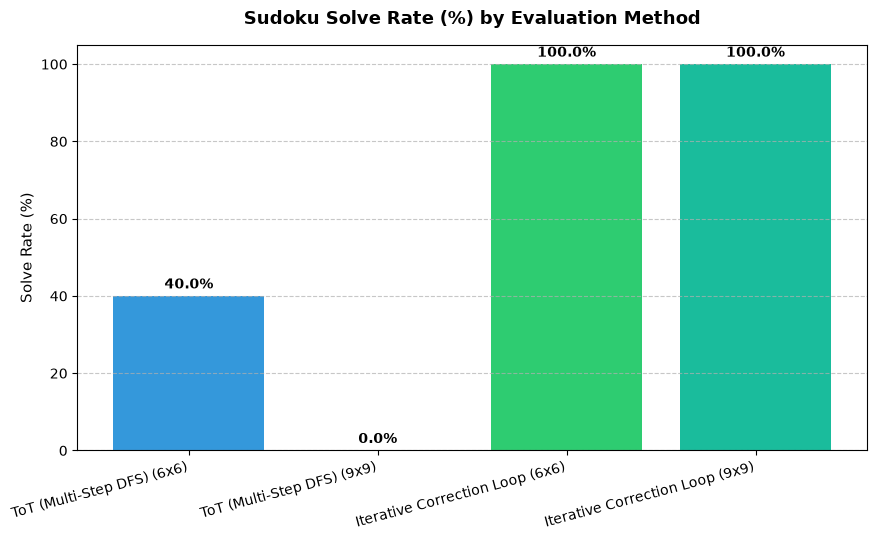

Saved solve rate chart to: solve_rate_tot.png


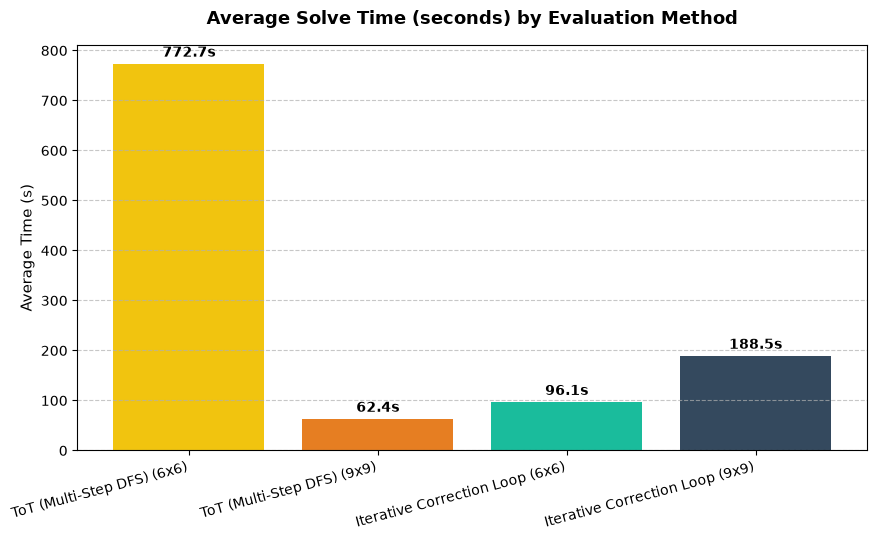

Saved solve time chart to: avg_time_tot.png


In [8]:
if not df.empty:
    # Map raw mode names to descriptive academic names
    mode_mapping = {
        'single-prompt': 'Iterative Correction Loop',
        'multi-prompt': 'ToT (Multi-Step DFS)'
    }
    plot_df = summary.copy()
    plot_df['display_mode'] = plot_df['mode'].map(mode_mapping)
    plot_df['label'] = plot_df['display_mode'] + ' (' + plot_df['grid_size'].astype(str) + 'x' + plot_df['grid_size'].astype(str) + ')'

    # 1. Solve Rate Plot
    plt.figure(figsize=(9, 5.5))
    bars = plt.bar(
        plot_df['label'],
        plot_df['solve_rate_pct'],
        color=['#3498db', '#9b59b6', '#2ecc71', '#1abc9c'][:len(plot_df)]
    )
    plt.title('Sudoku Solve Rate (%) by Evaluation Method', fontsize=13, fontweight='bold', pad=15)
    plt.ylabel('Solve Rate (%)', fontsize=11)
    plt.ylim(0, 105)
    plt.xticks(rotation=15, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Annotate bar values
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords='offset points',
                    ha='center', va='bottom', fontweight='bold')
                    
    plt.tight_layout()
    solve_rate_chart = charts_dir / 'solve_rate_tot.png'
    plt.savefig(solve_rate_chart, dpi=200)
    plt.show()
    print(f'Saved solve rate chart to: {solve_rate_chart.name}')

    # 2. Time Taken Plot
    plt.figure(figsize=(9, 5.5))
    bars = plt.bar(
        plot_df['label'],
        plot_df['avg_time_seconds'],
        color=['#f1c40f', '#e67e22', '#1abc9c', '#34495e'][:len(plot_df)]
    )
    plt.title('Average Solve Time (seconds) by Evaluation Method', fontsize=13, fontweight='bold', pad=15)
    plt.ylabel('Average Time (s)', fontsize=11)
    plt.xticks(rotation=15, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height:.1f}s',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontweight='bold')
                    
    plt.tight_layout()
    solve_time_chart = charts_dir / 'avg_time_tot.png'
    plt.savefig(solve_time_chart, dpi=200)
    plt.show()
    print(f'Saved solve time chart to: {solve_time_chart.name}')